# 02 · Comprensión de los datos

En esta fase se revisa a fondo el conjunto de datos asignado antes de usarlo: qué representa cada fila, qué tipo de información trae cada columna, qué tan completa y coherente es, y qué patrones muestra frente a los indicadores definidos en la sección 1.5 del notebook 01. Aquí no se modifica ni se limpia nada. Las figuras se muestran en el notebook y se guardan en `reports/figures/`. El resultado de esta fase son los hallazgos que se presentan después de cada bloque de análisis y una lista de decisiones (sección 2.8) que se ejecutarán en la fase 03, de preparación de los datos.

## 2.1 Importación de librerías y carga de datos

In [275]:
import io
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### Uso del color

| Color | Código HEX | Significado en este proyecto |
|---|---|---|
| Azul profundo | `#1F4E79` | Color principal: ventas netas, ticket, órdenes y distribuciones de valores. |
| Azul claro | `#6BAED6` | Color secundario: categorías y valores de referencia. |
| Degradado de azul | `#1F4E79` → `#6BAED6` | Ordena los grupos por magnitud: el valor más alto en azul profundo y el más bajo en azul claro. |
| Verde azulado | `#2A9D8F` | Destaca el mejor resultado o el más frecuente: categoría con más órdenes y mayor calificación. |
| Rojo controlado | `#D1495B` | Destaca el riesgo: el grupo con más devoluciones. |
| Grises (`#1F2933`, `#6B7280`, `#E5E7EB`) | — | Texto, ejes, líneas de referencia y elementos neutros. |

In [276]:
# Paleta del dashboard (teoría del color de la clase 3): cada color tiene un significado fijo
AZUL = "#1F4E79"          # color principal: ventas, ingresos y ticket
AZUL_CLARO = "#6BAED6"    # color secundario: volumen de órdenes y valores de referencia
VERDE = "#2A9D8F"         # énfasis positivo: lo que se cumple (sin retraso)
AMBAR = "#F4A261"         # advertencia y descuento
ROJO = "#D1495B"          # riesgo o valor negativo: retrasos y devoluciones altas
GRIS_TEXTO = "#1F2933"    # títulos y texto principal
GRIS_MEDIO = "#6B7280"    # ejes, etiquetas y líneas de referencia
GRIS_CLARO = "#E5E7EB"    # elementos neutros y cuadrícula
FONDO = "#FAFAF7"         # fondo de las figuras

# Escala divergente para correlaciones: rojo (negativa), blanco (cero), azul (positiva)
MAPA_CALOR = sns.blend_palette([ROJO, "white", AZUL], as_cmap=True)

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams.update({
    "figure.dpi": 100,
    "figure.facecolor": FONDO,
    "axes.facecolor": "white",
    "axes.edgecolor": GRIS_CLARO,
    "axes.titleweight": "bold",
    "axes.titlecolor": GRIS_TEXTO,
    "axes.labelcolor": GRIS_MEDIO,
    "xtick.color": GRIS_MEDIO,
    "ytick.color": GRIS_MEDIO,
    "grid.color": GRIS_CLARO,
    "text.color": GRIS_TEXTO,
})

# Formato de miles con punto, como se escribe en español
miles = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))

# Todas las figuras se guardan en reports/figures/ además de mostrarse en el notebook
CARPETA_FIGURAS = Path("../reports/figures")
CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)

def degradado(valores):
    """Degradado de azul: el valor más alto en azul profundo y el más bajo en azul claro."""
    posicion = pd.Series(list(valores)).rank(method="first", ascending=False).astype(int) - 1
    tonos = sns.blend_palette([AZUL, AZUL_CLARO], len(posicion))
    return [tonos[i] for i in posicion]

def destacar(valores, color):
    """Degradado de azul, pero el valor más alto se pinta con un color semántico (verde o rojo)."""
    colores = degradado(valores)
    colores[int(np.argmax(list(valores)))] = color
    return colores

def fmt_miles(valor):
    return f"{valor:,.0f}".replace(",", ".")

def fmt_pct(valor, decimales=1):
    return f"{valor:.{decimales}f} %".replace(".", ",")

def etiquetar(ax, barras, textos):
    """Escribe el valor de cada barra en su extremo."""
    for texto in ax.bar_label(barras, labels=textos, padding=3, fontsize=8, color=GRIS_TEXTO):
        texto.set_bbox({"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1})

def guardar(fig, nombre, intentos=5):
    """Guarda la figura en reports/figures/. Si el archivo está bloqueado un momento
    (por ejemplo, mientras OneDrive lo sincroniza), reintenta antes de rendirse."""
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    ruta = CARPETA_FIGURAS / nombre
    for _ in range(intentos):
        try:
            ruta.write_bytes(buffer.getvalue())
            return
        except OSError:
            time.sleep(1)
    print(f"Aviso: no se pudo guardar {nombre}; puede estar abierto o sincronizándose con OneDrive. "
          "La figura se muestra igual en el notebook.")

In [277]:
df = pd.read_csv("../data/raw/10_comercio_electronico.csv")

## 2.2 Descripción general del conjunto de datos

In [278]:
df.shape

(62000, 19)

In [279]:
df.head(10)

,id_orden,fecha_orden,ciudad_destino,departamento_destino,region,categoria,tipo_vendedor,dispositivo,fuente_trafico,valor_bruto_cop,descuento_pct,valor_neto_cop,metodo_pago,operador_entrega,dias_prometidos,dias_retraso,entrega_a_tiempo,devolucion_30d,calificacion_producto_1a5
0,ECOM-0000001,2026-01-13,Cartagena,Bolívar,Caribe,Juguetes,Venta directa,Móvil,Redes sociales,329897,5.34,312296,Tarjeta,Propia,4,0,Sí,No,5.00
1,ECOM-0000002,2024-12-13,Bogotá D.C.,Bogotá D.C.,Centro,Juguetes,Marketplace,Móvil,Redes sociales,65246,11.06,58033,Tarjeta,Propia,1,0,Sí,No,5.00
2,ECOM-0000003,2024-10-08,Bucaramanga,Santander,Nororiente,Tecnología,Marketplace,Móvil,Directo,388613,8.81,354383,PSE/Transferencia,Aliado logístico,2,0,Sí,No,4.00
3,ECOM-0000004,2024-01-01,Barranquilla,Atlántico,Caribe,Belleza,Marketplace,Móvil,Orgánico,40714,7.26,37757,Billetera,Propia,3,0,Sí,No,4.00
4,ECOM-0000005,2026-03-21,Pereira,Risaralda,Eje Cafetero,Deportes,Marketplace,Móvil,Redes sociales,341978,1.44,337065,PSE/Transferencia,Propia,3,0,Sí,No,5.00
5,ECOM-0000006,2024-02-11,Barranquilla,Atlántico,Caribe,Hogar,Marketplace,Desktop,Orgánico,64002,6.78,59665,Tarjeta,Propia,1,0,Sí,No,4.00
6,ECOM-0000007,2026-08-15,Bogotá D.C.,Bogotá D.C.,Centro,Hogar,Venta directa,Móvil,Pago,195303,3.65,188165,PSE/Transferencia,Propia,3,0,Sí,No,4.00
7,ECOM-0000008,2025-01-11,Ibagué,Tolima,Centro,Deportes,Marketplace,Móvil,Redes sociales,293365,4.28,280795,PSE/Transferencia,Aliado logístico,2,0,Sí,No,5.00
8,ECOM-0000009,2025-10-13,Bogotá D.C.,Bogotá D.C.,Centro,Moda,Marketplace,Móvil,Pago,106568,1.52,104952,Tarjeta,Propia,3,0,Sí,Sí,5.00
9,ECOM-0000010,2024-01-11,Bogotá D.C.,Bogotá D.C.,Centro,Moda,Venta directa,Móvil,Redes sociales,130477,4.19,125006,PSE/Transferencia,Propia,2,0,Sí,No,NaN


In [280]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62000 entries, 0 to 61999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_orden                   62000 non-null  object 
 1   fecha_orden                62000 non-null  object 
 2   ciudad_destino             62000 non-null  object 
 3   departamento_destino       62000 non-null  object 
 4   region                     62000 non-null  object 
 5   categoria                  62000 non-null  object 
 6   tipo_vendedor              62000 non-null  object 
 7   dispositivo                62000 non-null  object 
 8   fuente_trafico             62000 non-null  object 
 9   valor_bruto_cop            62000 non-null  int64  
 10  descuento_pct              62000 non-null  float64
 11  valor_neto_cop             62000 non-null  int64  
 12  metodo_pago                62000 non-null  object 
 13  operador_entrega           62000 non-null  obj

In [281]:
fechas = pd.to_datetime(df["fecha_orden"])
print("Primera orden:", fechas.min().date())
print("Última orden: ", fechas.max().date())
print()
print("Meses con órdenes en cada año:")
print(fechas.dt.to_period("M").groupby(fechas.dt.year).nunique().to_string())

Primera orden: 2024-01-01
Última orden:  2026-09-30

Meses con órdenes en cada año:
fecha_orden
2024    12
2025    12
2026     9


**Hallazgos.**

- **Registros y columnas.** El conjunto de datos tiene **62.000 registros** y **19 columnas**, donde cada fila representa una orden de compra realizada en la plataforma, identificada por `id_orden`.
- **Periodo cubierto.** Las órdenes van desde el **1 de enero de 2024** hasta el **30 de septiembre de 2026**, es decir, **33 meses**. Aunque los años 2024 y 2025 están completos, el año 2026 solo tiene registros de 9 meses, así que cualquier comparación entre años debe hacerse sobre el mismo periodo (enero a septiembre) para no concluir que 2026 vendió menos solo porque le faltan tres meses.
- **Tipos de datos.** La mayoría de las columnas llegó con un tipo adecuado: los valores en pesos y los días llegaron como números enteros (`int64`), el descuento como decimal (`float64`) y las variables descriptivas como texto (`object`). Sin embargo, dos columnas deben cambiar en la fase 03: `fecha_orden` llegó como texto y debe convertirse a fecha para poder analizar la evolución en el tiempo, y `devolucion_30d` llegó como texto con valores "Sí" y "No" y debe convertirse a 1 y 0 para calcular directamente el porcentaje de devoluciones. `entrega_a_tiempo` también llegó como texto con "Sí" y "No", pero no se transforma porque repite la información de `dias_retraso` y se recomienda eliminarla (sección 2.3).
- **Calificación del producto.** La variable `calificacion_producto_1a5` aparece como decimal aunque solo toma valores enteros, así que debe convertirse a tipo entero. Además, esta variable es la **única columna con valores nulos**: tiene **1.364 órdenes sin calificación (2,2 %)**.

### 2.2.1 Clasificación de las variables

| Variable | Qué representa | Naturaleza | Función en el dashboard |
|---|---|---|---|
| `id_orden` | Código único de cada orden | Identificador | Conteo de órdenes |
| `fecha_orden` | Día en que se hizo la compra | Temporal | Dimensión y filtro de tiempo |
| `ciudad_destino` | Ciudad a la que se envía el pedido | Geográfica | Dimensión y filtro |
| `departamento_destino` | Departamento de la ciudad de destino | Geográfica | Dimensión (mapa) |
| `region` | Región del país a la que pertenece el departamento | Geográfica | Dimensión y filtro |
| `categoria` | Tipo de producto comprado | Categórica | Dimensión y filtro |
| `tipo_vendedor` | Si vende un tercero (marketplace) o la propia plataforma | Categórica | Dimensión y filtro |
| `dispositivo` | Desde dónde se hizo la compra (móvil, computador, tableta) | Categórica | Dimensión |
| `fuente_trafico` | Canal por el que llegó el cliente | Categórica | Dimensión y filtro |
| `valor_bruto_cop` | Valor de la orden antes del descuento, en pesos | Numérica | Métrica de comparación |
| `descuento_pct` | Porcentaje de descuento aplicado | Numérica | KPI (descuento promedio) |
| `valor_neto_cop` | Valor pagado después del descuento, en pesos | Numérica | KPI (ventas netas y ticket promedio) |
| `metodo_pago` | Medio con el que se pagó | Categórica | Dimensión y filtro |
| `operador_entrega` | Quién entrega el pedido | Categórica | Dimensión y filtro |
| `dias_prometidos` | Días de entrega prometidos al cliente | Numérica (discreta) | Dimensión de comparación |
| `dias_retraso` | Días que la entrega se pasó del plazo prometido | Numérica (discreta) | Métrica de comparación y KPI (% entrega a tiempo = órdenes con 0 días de retraso) |
| `entrega_a_tiempo` | Si el pedido llegó dentro del plazo (Sí/No) | Binaria | Ninguna: repite la información de `dias_retraso` (sección 2.3) |
| `devolucion_30d` | Si el cliente devolvió el pedido en los 30 días siguientes (Sí/No) | Binaria | KPI (% devoluciones) |
| `calificacion_producto_1a5` | Calificación que el cliente dio al producto, de 1 a 5 | Numérica (ordinal) | KPI (calificación promedio) |

## 2.3 Calidad de los datos: duplicados, valores nulos e inconsistencias

In [282]:
print("Filas duplicadas:", df.duplicated().sum())
print("Valores únicos de id_orden:", df["id_orden"].nunique(), "de", len(df), "filas")

Filas duplicadas: 0
Valores únicos de id_orden: 62000 de 62000 filas


In [283]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
})
nulos.sort_values("nulos", ascending=False).head(5)

,nulos,% nulos
calificacion_producto_1a5,1364,2.20
fecha_orden,0,0.00
id_orden,0,0.00
ciudad_destino,0,0.00
departamento_destino,0,0.00


In [284]:
# ¿Los nulos de la calificación se concentran en algún segmento?
sin_calificacion = df["calificacion_producto_1a5"].isna()
for col in ["categoria", "devolucion_30d", "entrega_a_tiempo"]:
    print(f"\n% de órdenes sin calificación según {col}:")
    print((sin_calificacion.groupby(df[col]).mean() * 100).round(2).to_string())


% de órdenes sin calificación según categoria:
categoria
Belleza      2.05
Deportes     2.62
Hogar        2.39
Juguetes     1.78
Mascotas     1.94
Moda         2.19
Tecnología   2.22

% de órdenes sin calificación según devolucion_30d:
devolucion_30d
No   2.22
Sí   1.96

% de órdenes sin calificación según entrega_a_tiempo:
entrega_a_tiempo
No   2.47
Sí   2.16


**Hallazgos.**

- **Duplicados.** No hay filas duplicadas y `id_orden` es único en las **62.000** órdenes, así que cada fila es una compra distinta.
- **Valores nulos.** La única columna con valores vacíos es `calificacion_producto_1a5`, con **1.364 órdenes sin calificación (2,2 %)**; las otras 18 columnas están completas.
- **Distribución de los nulos.** Los valores nulos de la columna `calificacion_producto_1a5` no se concentran en ningún grupo: por categoría van de **1,78 %** (Juguetes) a **2,62 %** (Deportes), y casi no cambian entre órdenes devueltas y no devueltas (**1,96 %** frente a **2,22 %**) ni entre entregas a tiempo y tardías (**2,16 %** frente a **2,47 %**). Todo indica que son clientes que simplemente no calificaron, repartidos al azar, es decir que no hay necesidad de imputarlos.

In [285]:
# Coherencia geográfica: cada ciudad debería tener un solo departamento y cada departamento una sola región
print("Máximo de departamentos por ciudad:", df.groupby("ciudad_destino")["departamento_destino"].nunique().max())
print("Máximo de regiones por departamento:", df.groupby("departamento_destino")["region"].nunique().max())
df.groupby(["region", "departamento_destino"])["ciudad_destino"].unique().to_frame("ciudades")

Máximo de departamentos por ciudad: 1
Máximo de regiones por departamento: 1


ciudades
region       departamento_destino                 
Caribe       Atlántico              [Barranquilla]
             Bolívar                   [Cartagena]
             Magdalena               [Santa Marta]
Centro       Bogotá D.C.             [Bogotá D.C.]
             Tolima                       [Ibagué]
Eje Cafetero Caldas                    [Manizales]
             Risaralda                   [Pereira]
Noroccidente Antioquia                  [Medellín]
Nororiente   Norte de Santander           [Cúcuta]
             Santander               [Bucaramanga]
Orinoquía    Meta                  [Villavicencio]
Suroccidente Valle del Cauca                [Cali]

In [286]:
# Coherencia entre entrega_a_tiempo y dias_retraso.
# Lo esperado: toda orden marcada "Sí" (a tiempo) tiene 0 días de retraso, y toda orden marcada "No" tiene al menos 1 día de retraso.
retraso = np.where(df["dias_retraso"] > 0, "Con días de retraso", "Sin días de retraso")
tabla = pd.crosstab(df["entrega_a_tiempo"].map({"Sí": "Marcada a tiempo (Sí)", "No": "Marcada tarde (No)"}), retraso)
tabla.index.name = "entrega_a_tiempo"
tabla.columns.name = "dias_retraso"

contradicciones = tabla.loc["Marcada a tiempo (Sí)", "Con días de retraso"] + tabla.loc["Marcada tarde (No)", "Sin días de retraso"]
print("Órdenes que se contradicen entre las dos columnas:", contradicciones)
tabla

Órdenes que se contradicen entre las dos columnas: 0


dias_retraso,Con días de retraso,Sin días de retraso
entrega_a_tiempo,,
Marcada a tiempo (Sí),0,54604
Marcada tarde (No),7396,0


In [287]:
# Coherencia del valor neto: el valor pagado debería ser el valor bruto menos el descuento.
# Se recalcula el valor neto y se compara con el que trae la base.
neto_calculado = df["valor_bruto_cop"] * (1 - df["descuento_pct"] / 100)
diferencia = (df["valor_neto_cop"] - neto_calculado).abs()
diferencia_relativa = diferencia / df["valor_neto_cop"] * 100

# Cinco órdenes de ejemplo para ver qué se está comparando
ejemplo = df[["id_orden", "valor_bruto_cop", "descuento_pct", "valor_neto_cop"]].head(5).assign(
    neto_calculado=neto_calculado.head(5).round(0), diferencia_en_pesos=diferencia.head(5).round(0))
ejemplo

,id_orden,valor_bruto_cop,descuento_pct,valor_neto_cop,neto_calculado,diferencia_en_pesos
0,ECOM-0000001,329897,5.34,312296,"312,281.00",15.00
1,ECOM-0000002,65246,11.06,58033,"58,030.00",3.00
2,ECOM-0000003,388613,8.81,354383,"354,376.00",7.00
3,ECOM-0000004,40714,7.26,37757,"37,758.00",1.00
4,ECOM-0000005,341978,1.44,337065,"337,054.00",11.00


In [288]:
# Resumen de las diferencias en toda la base
pd.Series({
    "Diferencia típica (mediana), en pesos": diferencia.median(),
    "Diferencia promedio, en pesos": diferencia.mean(),
    "Diferencia más grande, en pesos": diferencia.max(),
    "Diferencia más grande, como % del valor neto": diferencia_relativa.max(),
    "Órdenes con diferencia de más de 100 pesos": (diferencia > 100).sum(),
    "Órdenes con diferencia de más de 1.000 pesos": (diferencia > 1000).sum(),
}).round(3).to_frame("valor")

,valor
"Diferencia típica (mediana), en pesos",2.59
"Diferencia promedio, en pesos",5.98
"Diferencia más grande, en pesos",319.50
"Diferencia más grande, como % del valor neto",0.01
Órdenes con diferencia de más de 100 pesos,95.00
Órdenes con diferencia de más de 1.000 pesos,0.00


In [289]:
# ¿Se explica por redondeo? El descuento viene con 2 decimales, así que puede estar redondeado hasta en 0,005 puntos, lo que mueve el valor neto hasta bruto × 0,005 % (más medio peso).
margen_redondeo = df["valor_bruto_cop"] * 0.005 / 100 + 0.5
explicado = diferencia <= margen_redondeo
print(f"Órdenes cuya diferencia cabe en el margen de redondeo: {explicado.mean() * 100:.2f} %")
print(f"Órdenes fuera del margen: {(~explicado).sum()}  |  diferencia máxima entre ellas: "
      f"{diferencia[~explicado].max():.0f} pesos")

Órdenes cuya diferencia cabe en el margen de redondeo: 99.71 %
Órdenes fuera del margen: 178  |  diferencia máxima entre ellas: 41 pesos


In [290]:
# Valores imposibles
pd.Series({
    "valor_bruto_cop <= 0": (df["valor_bruto_cop"] <= 0).sum(),
    "valor_neto_cop <= 0": (df["valor_neto_cop"] <= 0).sum(),
    "descuento_pct fuera de 0–100": (~df["descuento_pct"].between(0, 100)).sum(),
    "valor neto mayor que el bruto": (df["valor_neto_cop"] > df["valor_bruto_cop"]).sum(),
    "calificación fuera de 1–5": (~df["calificacion_producto_1a5"].dropna().between(1, 5)).sum(),
    "dias_prometidos negativos": (df["dias_prometidos"] < 0).sum(),
    "dias_retraso negativos": (df["dias_retraso"] < 0).sum(),
    "órdenes sin descuento (0 %)": (df["descuento_pct"] == 0).sum(),
    "órdenes con entrega prometida el mismo día (0 días)": (df["dias_prometidos"] == 0).sum(),
}).to_frame("cantidad")

,cantidad
valor_bruto_cop <= 0,0
valor_neto_cop <= 0,0
descuento_pct fuera de 0–100,0
valor neto mayor que el bruto,0
calificación fuera de 1–5,0
dias_prometidos negativos,0
dias_retraso negativos,0
órdenes sin descuento (0 %),8016
órdenes con entrega prometida el mismo día (0 días),2401


**Hallazgos.**

- **Coherencia geográfica.** Cada una de las **12 ciudades** pertenece a un solo departamento y cada uno de los **12 departamentos** a una sola región, de modo que la jerarquía región → departamento → ciudad se puede usar en el dashboard para navegar de lo general a lo particular.
- **Entrega a tiempo y días de retraso.** Las dos columnas dicen exactamente lo mismo: las **54.604** órdenes marcadas como "Sí" no tienen días de retraso y las **7.396** marcadas como "No" tienen al menos uno, sin ninguna contradicción. Como `entrega_a_tiempo` se puede obtener directamente de `dias_retraso` tener las dos columnas es redundante.
- **Valor neto.** Al recalcularlo como valor bruto menos el descuento, la diferencia es de apenas unos pesos: la típica es de **2,59 pesos**, el promedio de **5,98 pesos** y la más grande de **319,50 pesos**, que equivale a menos del **0,02 %** del valor de esa orden. Solo **95 órdenes** difieren en más de 100 pesos y ninguna en más de 1.000. El **99,71 %** de las órdenes cae dentro del margen que deja redondear el descuento a dos decimales, y las **178** restantes difieren como máximo en **41 pesos**. En la fase 03 se usará `valor_neto_cop` tal como viene, porque es lo que el cliente realmente pagó.
- **Valores imposibles.** No hay montos en cero o negativos, descuentos fuera de 0–100 %, valores netos mayores que el bruto, calificaciones fuera de 1–5 ni días negativos.
- **Casos llamativos pero válidos.** Hay **8.016 órdenes sin descuento**, que simplemente se vendieron a precio completo, y **2.401 órdenes con entrega prometida el mismo día** (0 días). Ambos casos son válidos.

## 2.4 Variables cuantitativas: estadísticas descriptivas y valores atípicos

In [291]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
valor_bruto_cop,"62,000.00","273,997.10","365,690.74","5,105.00","80,222.25","153,603.50","313,021.25","9,554,589.00"
descuento_pct,"62,000.00",9.55,7.14,0.00,3.62,9.04,14.48,41.84
valor_neto_cop,"62,000.00","247,716.08","331,577.78","4,145.00","72,244.75","138,391.50","282,627.00","9,000,119.00"
dias_prometidos,"62,000.00",2.48,1.28,0.00,2.00,2.00,3.00,5.00
dias_retraso,"62,000.00",0.30,0.90,0.00,0.00,0.00,0.00,4.00
calificacion_producto_1a5,"60,636.00",4.27,0.66,2.00,4.00,4.00,5.00,5.00


### 2.4.1 Valor de la orden y descuento

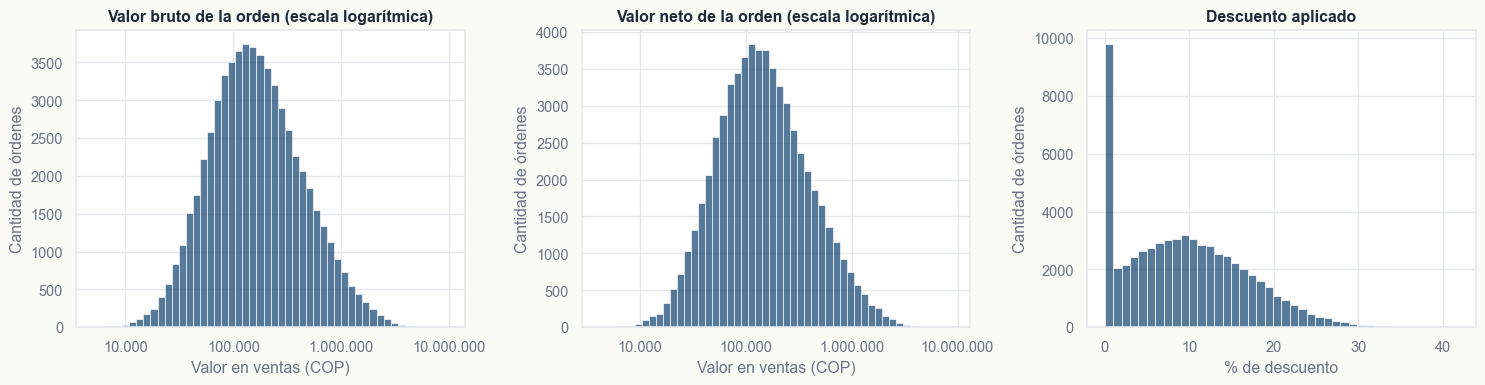

In [292]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo in zip(axes[:2], ["valor_bruto_cop", "valor_neto_cop"],
                           ["Valor bruto de la orden", "Valor neto de la orden"]):
    sns.histplot(df[col], bins=50, log_scale=True, color=AZUL, ax=ax)
    ax.set_title(f"{titulo} (escala logarítmica)")
    ax.set_xlabel("Valor en ventas (COP)")
    ax.set_ylabel("Cantidad de órdenes")
    ax.xaxis.set_major_formatter(miles)
sns.histplot(df["descuento_pct"], bins=42, color=AZUL, ax=axes[2])
axes[2].set_title("Descuento aplicado")
axes[2].set_xlabel("% de descuento")
axes[2].set_ylabel("Cantidad de órdenes")
plt.tight_layout()
guardar(fig, "distribucion_valor_y_descuento.png")
plt.show()

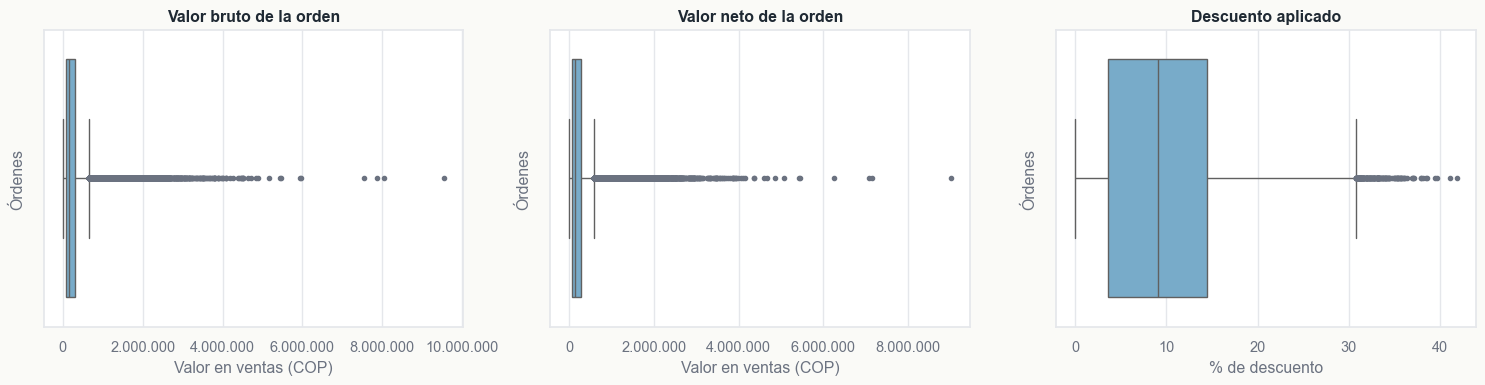

In [293]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo, eje_x in zip(axes, ["valor_bruto_cop", "valor_neto_cop", "descuento_pct"],
                                  ["Valor bruto de la orden", "Valor neto de la orden", "Descuento aplicado"],
                                  ["Valor en ventas (COP)", "Valor en ventas (COP)", "% de descuento"]):
    sns.boxplot(x=df[col], color=AZUL_CLARO, flierprops={"markerfacecolor": GRIS_MEDIO, "markeredgecolor": GRIS_MEDIO,
                                                         "markersize": 3}, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel(eje_x)
    ax.set_ylabel("Órdenes")
axes[0].xaxis.set_major_formatter(miles)
axes[1].xaxis.set_major_formatter(miles)
plt.tight_layout()
guardar(fig, "boxplots_valor_y_descuento.png")
plt.show()

In [294]:
# Conteo de atípicos con la regla del rango intercuartílico (IQR)
def atipicos_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    limite_superior = q3 + 1.5 * (q3 - q1)
    limite_inferior = q1 - 1.5 * (q3 - q1)
    return pd.Series({
        "límite inferior": limite_inferior,
        "límite superior": limite_superior,
        "atípicos": ((serie < limite_inferior) | (serie > limite_superior)).sum(),
        "% atípicos": ((serie < limite_inferior) | (serie > limite_superior)).mean() * 100,
    })

df[["valor_bruto_cop", "valor_neto_cop", "descuento_pct"]].apply(atipicos_iqr).T

,límite inferior,límite superior,atípicos,% atípicos
valor_bruto_cop,"-268,976.25","662,219.75","5,635.00",9.09
valor_neto_cop,"-243,328.62","598,200.38","5,633.00",9.09
descuento_pct,-12.67,30.77,195.00,0.31


In [295]:
# ¿A qué categoría pertenecen las órdenes atípicas por valor neto?
limite = atipicos_iqr(df["valor_neto_cop"])["límite superior"]
atipicas = df[df["valor_neto_cop"] > limite]
(atipicas["categoria"].value_counts(normalize=True) * 100).round(1).to_frame("% de las órdenes atípicas")

,% de las órdenes atípicas
categoria,
Tecnología,84.80
Hogar,8.10
Deportes,3.60
Moda,2.20
Belleza,0.60
Juguetes,0.50
Mascotas,0.20


In [296]:
df.nlargest(10, "valor_neto_cop")[["id_orden", "categoria", "tipo_vendedor", "valor_bruto_cop",
                                   "descuento_pct", "valor_neto_cop", "devolucion_30d"]]

,id_orden,categoria,tipo_vendedor,valor_bruto_cop,descuento_pct,valor_neto_cop,devolucion_30d
34043,ECOM-0034044,Tecnología,Marketplace,9554589,5.80,9000119,No
41230,ECOM-0041231,Tecnología,Marketplace,8050903,11.24,7145662,No
2099,ECOM-0002100,Tecnología,Venta directa,7872541,10.18,7071345,No
30758,ECOM-0030759,Tecnología,Venta directa,7537684,17.12,6247439,No
26246,ECOM-0026247,Tecnología,Marketplace,5448085,0.00,5448085,No
58037,ECOM-0058038,Tecnología,Marketplace,5955128,8.95,5422257,No
46975,ECOM-0046976,Tecnología,Marketplace,5926729,14.27,5080982,No
54597,ECOM-0054598,Tecnología,Marketplace,4896742,0.53,4870975,No
7916,ECOM-0007917,Tecnología,Marketplace,5166097,9.80,4659870,No
33029,ECOM-0033030,Tecnología,Marketplace,5472477,16.14,4589283,No


In [297]:
# Valor neto típico de cada categoría
df.groupby("categoria")["valor_neto_cop"].describe()[["mean", "50%", "75%", "max"]] \
  .rename(columns={"mean": "promedio", "50%": "mediana", "75%": "percentil 75", "max": "máximo"}) \
  .sort_values("mediana", ascending=False)

,promedio,mediana,percentil 75,máximo
categoria,,,,
Tecnología,"610,971.02","461,328.00","764,871.00","9,000,119.00"
Hogar,"220,468.58","168,440.00","277,486.00","3,994,276.00"
Deportes,"190,668.37","143,521.00","233,539.75","2,434,535.00"
Moda,"138,312.12","103,359.00","172,068.00","1,641,895.00"
Juguetes,"118,032.29","89,777.00","149,273.00","1,287,202.00"
Belleza,"104,755.23","77,987.00","131,037.00","1,240,506.00"
Mascotas,"90,950.46","67,743.00","113,707.00","1,040,950.00"


**Hallazgos.**

- **Valor de las órdenes.** El valor de las órdenes es muy desigual: la mitad de las órdenes cuesta menos de **$138.392** netos, pero el promedio sube a **$247.716** por unas pocas compras muy grandes; la más alta llega a **$9.000.119**. Por eso los histogramas se muestran en escala logarítmica, y por eso el promedio solo, sin la mediana, puede dar una idea equivocada del valor de una compra típica.
- **Valores atípicos.** Con la regla del rango intercuartílico, **5.633 órdenes (9,1 %)** quedan como atípicas por valor neto. Sin embargo, no son errores: el **84,8 %** de ellas son de **Tecnología**, la categoría con productos más caros (su mediana es **$461.328**, frente a **$67.743** de Mascotas), y las 10 órdenes más caras también pertenecen a esta categoría.
- **Tratamiento de los atípicos.** Son compras legítimas con un alto valor, así que en la fase 03 **se deberían conservar**.
- **Descuento.** Se comporta de forma ordenada: va de **0 %** a **41,84 %**, con un promedio de **9,55 %**. La barra alta en 0 del histograma corresponde a las **8.016 órdenes sin descuento (12,9 %)**; no requiere tratamiento.

### 2.4.2 Variables de entrega y calificación

In [298]:
for col in ["dias_prometidos", "dias_retraso", "calificacion_producto_1a5"]:
    frecuencia = df[col].value_counts(dropna=False).sort_index()
    print(f"\n{col}")
    print(pd.DataFrame({"órdenes": frecuencia, "%": (frecuencia / len(df) * 100).round(1)}).to_string())


dias_prometidos
                 órdenes     %
dias_prometidos               
0                   2401  3.90
1                  12487 20.10
2                  18473 29.80
3                  15056 24.30
4                   8618 13.90
5                   4965  8.00

dias_retraso
              órdenes     %
dias_retraso               
0               54604 88.10
1                1860  3.00
2                1823  2.90
3                1879  3.00
4                1834  3.00

calificacion_producto_1a5
                           órdenes     %
calificacion_producto_1a5               
2.00                           193  0.30
3.00                          6455 10.40
4.00                         30484 49.20
5.00                         23504 37.90
NaN                           1364  2.20


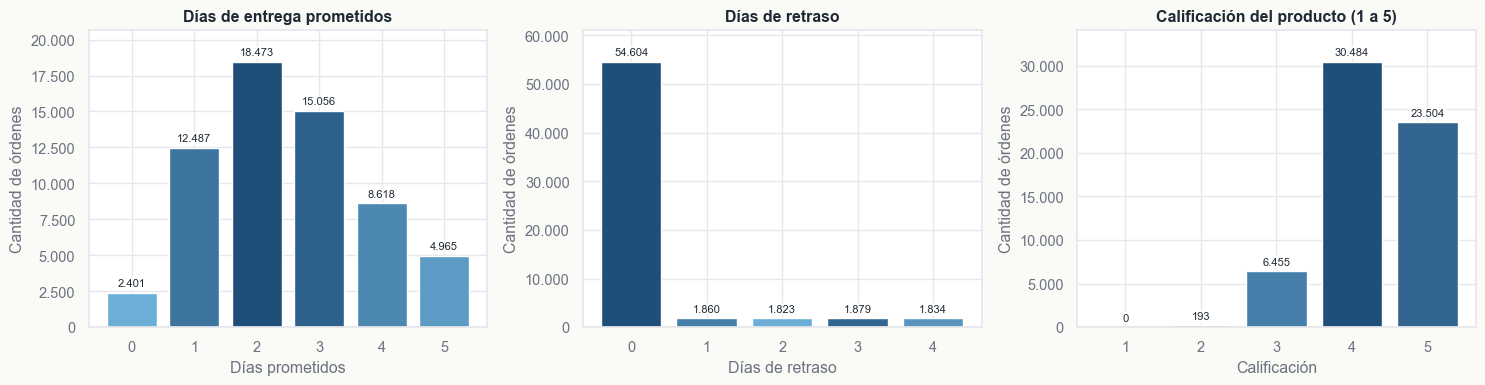

In [299]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titulos = ["Días de entrega prometidos", "Días de retraso", "Calificación del producto (1 a 5)"]
ejes_x = ["Días prometidos", "Días de retraso", "Calificación"]
for ax, col, titulo, eje_x in zip(axes, ["dias_prometidos", "dias_retraso", "calificacion_producto_1a5"], titulos, ejes_x):
    frecuencia = df[col].value_counts().sort_index()
    if col == "calificacion_producto_1a5":
        frecuencia = frecuencia.reindex(range(1, 6), fill_value=0)  # la nota 1 se muestra aunque tenga 0 órdenes
    barras = ax.bar(frecuencia.index.astype(int).astype(str), frecuencia.values, color=degradado(frecuencia.values))
    etiquetar(ax, barras, [fmt_miles(v) for v in frecuencia.values])
    ax.margins(y=0.12)
    ax.set_title(titulo)
    ax.set_xlabel(eje_x)
    ax.set_ylabel("Cantidad de órdenes")
    ax.yaxis.set_major_formatter(miles)
plt.tight_layout()
guardar(fig, "distribucion_entrega_y_calificacion.png")
plt.show()

**Hallazgos.**

- **Días prometidos.** A la mayoría de los clientes se les prometen entre **1 y 3 días** de entrega (2 días es lo más común, con **29,8 %** de las órdenes), y solo el **3,9 %** recibe una promesa de entrega el mismo día.
- **Días de retraso.** El retraso es poco frecuente pero, cuando ocurre, no es leve: el **88,1 %** de las órdenes llega sin retraso, y el **11,9 %** restante se reparte casi por igual entre 1, 2, 3 y 4 días de retraso (unas 1.800 órdenes en cada caso).
- **Calificación.** **4** es la nota más frecuente (**49,2 %** de las órdenes), seguida de **5** (**37,9 %**), mientras que las notas de **3** (10,4 %) y **2** (0,3 %) son pocas y **nadie calificó con 1**.

### 2.4.3 Relación entre variables numéricas

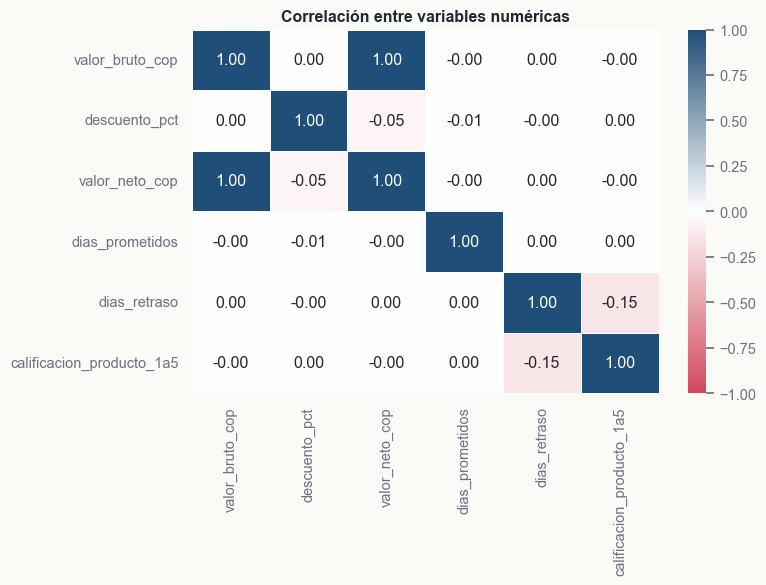

In [300]:
numericas = ["valor_bruto_cop", "descuento_pct", "valor_neto_cop",
             "dias_prometidos", "dias_retraso", "calificacion_producto_1a5"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".2f", cmap=MAPA_CALOR, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout()
guardar(fig, "correlacion_variables_numericas.png")
plt.show()

**Hallazgos.**

- **Independencia general.** Casi todas las variables numéricas son independientes entre sí, con correlaciones cercanas a cero, salvo dos relaciones.
- **Valor bruto y valor neto.** Están casi perfectamente relacionados (**0,995**), lo que tiene sentido porque el valor neto es igual al valor bruto menos un descuento pequeño. 
- **Retraso y calificación.** `dias_retraso` y `calificacion_producto_1a5` tienen una correlación **negativa de -0,15**, es decir, a más días de retraso, menor calificación. Es una relación moderada, pero es la única señal clara entre las variables de entrega y la experiencia del cliente.
- **Descuento y valor de la orden.** El descuento no está relacionado con el valor bruto de la orden, es decir, **los descuentos más altos no vienen acompañados de compras más grandes**.

## 2.5 Variables cualitativas: describe y frecuencias

In [301]:
categoricas = ["ciudad_destino", "departamento_destino", "region", "categoria", "tipo_vendedor",
               "dispositivo", "fuente_trafico", "metodo_pago", "operador_entrega"]
df[categoricas].describe().T

,count,unique,top,freq
ciudad_destino,62000,12,Bogotá D.C.,15035
departamento_destino,62000,12,Bogotá D.C.,15035
region,62000,7,Centro,18181
categoria,62000,7,Tecnología,13129
tipo_vendedor,62000,2,Marketplace,39912
dispositivo,62000,3,Móvil,42937
fuente_trafico,62000,5,Orgánico,17417
metodo_pago,62000,4,Tarjeta,26626
operador_entrega,62000,3,Propia,28475


In [302]:
for col in categoricas:
    frecuencia = df[col].value_counts()
    print(f"\n=== {col} — {df[col].nunique()} categorías ===")
    print(pd.DataFrame({"órdenes": frecuencia, "%": (frecuencia / len(df) * 100).round(1)}).to_string())


=== ciudad_destino — 12 categorías ===
                órdenes     %
ciudad_destino               
Bogotá D.C.       15035 24.20
Medellín           8640 13.90
Cali               7333 11.80
Barranquilla       5050  8.10
Bucaramanga        4404  7.10
Cartagena          3757  6.10
Ibagué             3146  5.10
Villavicencio      3124  5.00
Santa Marta        3060  4.90
Pereira            3042  4.90
Cúcuta             3023  4.90
Manizales          2386  3.80

=== departamento_destino — 12 categorías ===
                      órdenes     %
departamento_destino               
Bogotá D.C.             15035 24.20
Antioquia                8640 13.90
Valle del Cauca          7333 11.80
Atlántico                5050  8.10
Santander                4404  7.10
Bolívar                  3757  6.10
Tolima                   3146  5.10
Meta                     3124  5.00
Magdalena                3060  4.90
Risaralda                3042  4.90
Norte de Santander       3023  4.90
Caldas                   2

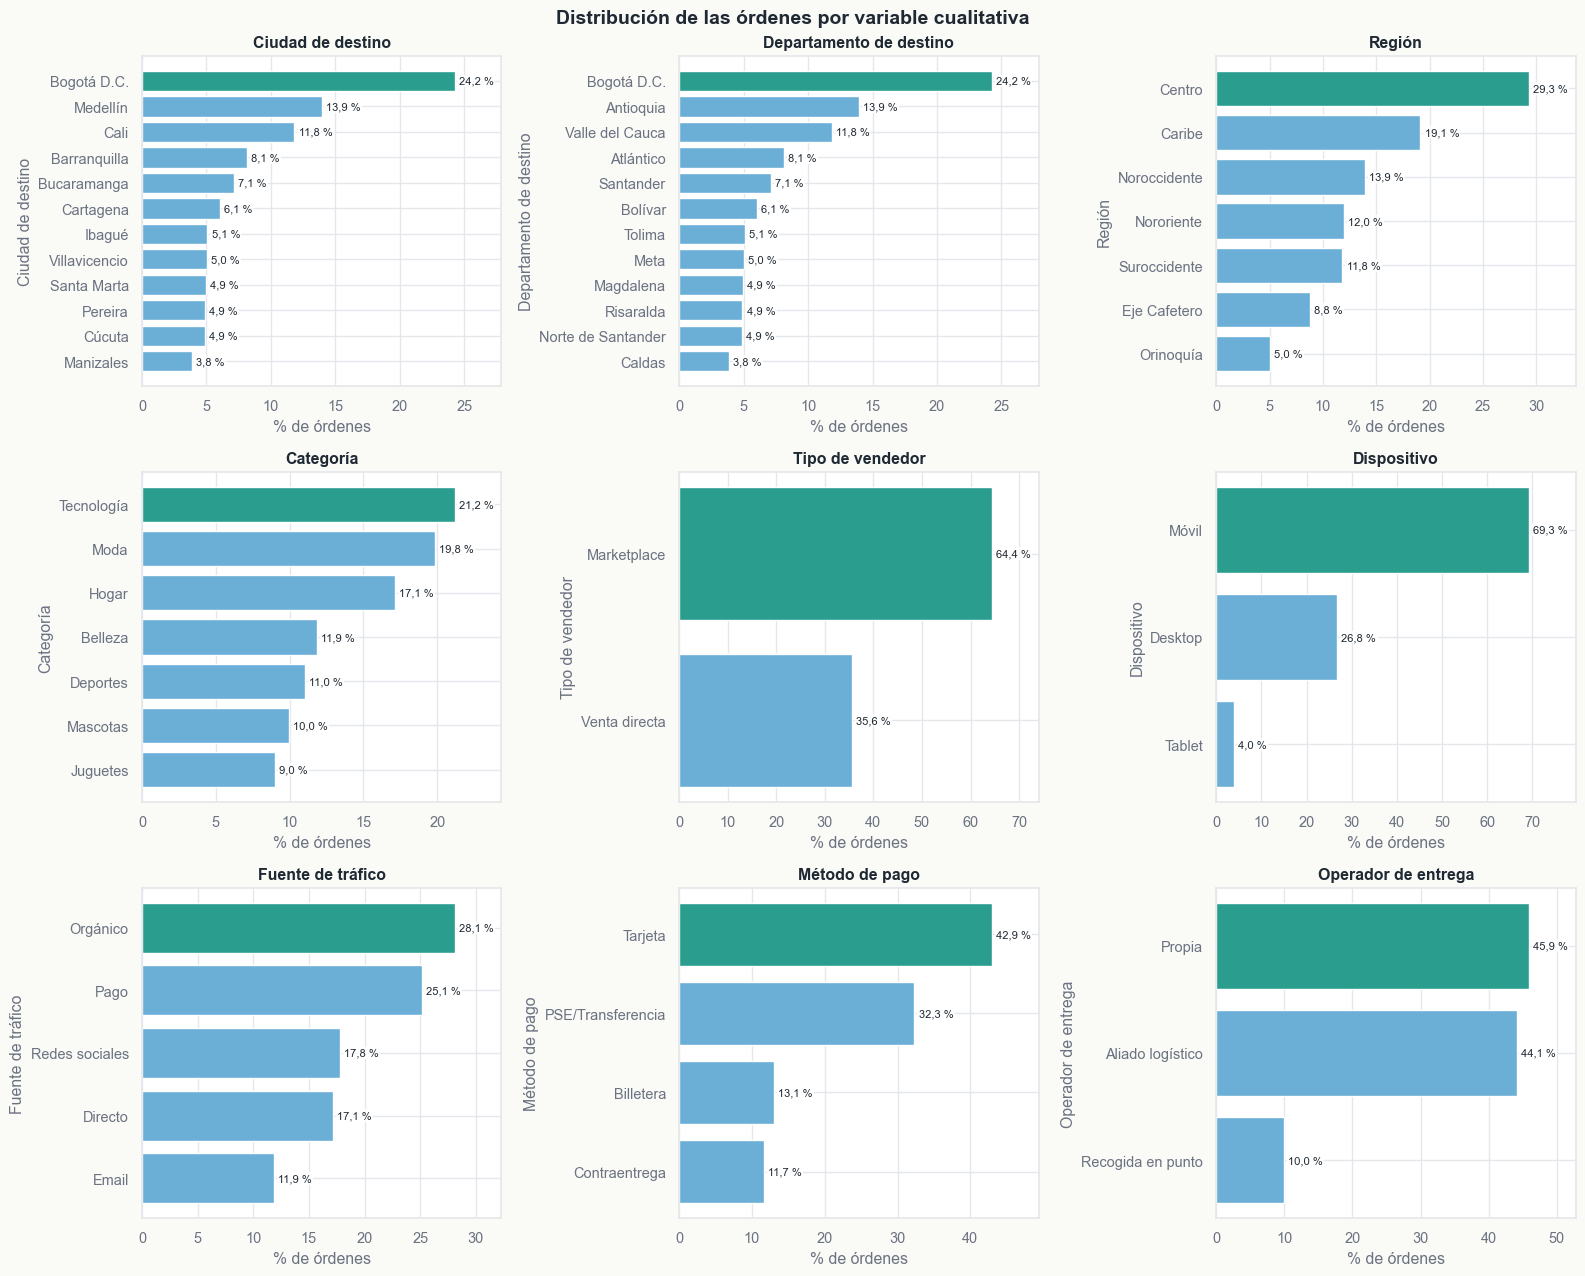

In [303]:
nombres = {"ciudad_destino": "Ciudad de destino", "departamento_destino": "Departamento de destino",
           "region": "Región", "categoria": "Categoría", "tipo_vendedor": "Tipo de vendedor",
           "dispositivo": "Dispositivo", "fuente_trafico": "Fuente de tráfico",
           "metodo_pago": "Método de pago", "operador_entrega": "Operador de entrega"}

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.ravel(), categoricas):
    porcentaje = df[col].value_counts(normalize=True) * 100
    colores = [VERDE if valor == porcentaje.max() else AZUL_CLARO for valor in porcentaje.values]
    barras = ax.barh(porcentaje.index[::-1], porcentaje.values[::-1], color=colores[::-1])
    etiquetar(ax, barras, [fmt_pct(v) for v in porcentaje.values[::-1]])
    ax.margins(x=0.15)
    ax.set_title(nombres[col])
    ax.set_xlabel("% de órdenes")
    ax.set_ylabel(nombres[col])
plt.suptitle("Distribución de las órdenes por variable cualitativa", fontsize=14, fontweight="bold", color=GRIS_TEXTO)
plt.tight_layout()
guardar(fig, "frecuencias_variables_cualitativas.png")
plt.show()

**Hallazgos.**

- **Geografía.** Las órdenes se concentran en las ciudades grandes: Bogotá D.C. recibe el **24,2 %**, seguida de Medellín (**13,9 %**) y Cali (**11,8 %**). Por región, Centro (**29,3 %**) y Caribe (**19,1 %**) suman casi la mitad, mientras que Orinoquía, con una sola ciudad (Villavicencio), tiene el **5,0 %**. Como `ciudad_destino` y `departamento_destino` tienen una relación uno a uno, aportan la misma información y la diferencia es solo de presentación.
- **Producto.** Tecnología (**21,2 %**), Moda (**19,8 %**) y Hogar (**17,1 %**) son las categorías con más órdenes.
- **Tipo de vendedor.** En **Marketplace**, un vendedor externo (otra empresa o tienda) publica su producto en la plataforma y esta cobra una comisión, esta categoría representó el **64,4 %** de las órdenes. Mientras que, en **Venta directa**, la plataforma vende su propio inventario y representó el **35,6 %** de las órdenes.
- **Dispositivo.** El **69,3 %** de las compras se hace desde el celular, el **26,8 %** desde un computador y el **4,0 %** desde una tableta.
- **Fuente de tráfico.** La fuente de tráfico más común es la **búsqueda orgánica** (**28,1 %**), es decir, clientes que buscaron en Google u otro buscador y entraron por un resultado normal, sin que la plataforma pagara por aparecer. Le siguen la **publicidad pagada** (**25,1 %**), que son anuncios por los que la plataforma sí paga; las **redes sociales** (**17,8 %**); el tráfico **directo** (**17,1 %**), de clientes que escribieron la dirección o abrieron la aplicación; y el **email** (**11,9 %**), de clientes que llegaron desde un correo de la plataforma.
- **Medio de pago.** Los clientes pagan principalmente con tarjeta (**42,9 %**) o PSE/transferencia (**32,3 %**), seguidos de billetera digital (**13,0 %**) y pago contra entrega (**11,7 %**).
- **Operador de entrega.** El **45,9 %** de las órdenes las entrega la propia plataforma con su operación logística, el **44,1 %** una empresa de mensajería aliada, y en el **10,0 %** restante es el cliente quien recoge el pedido en un punto autorizado.

## 2.6 Dimensión temporal

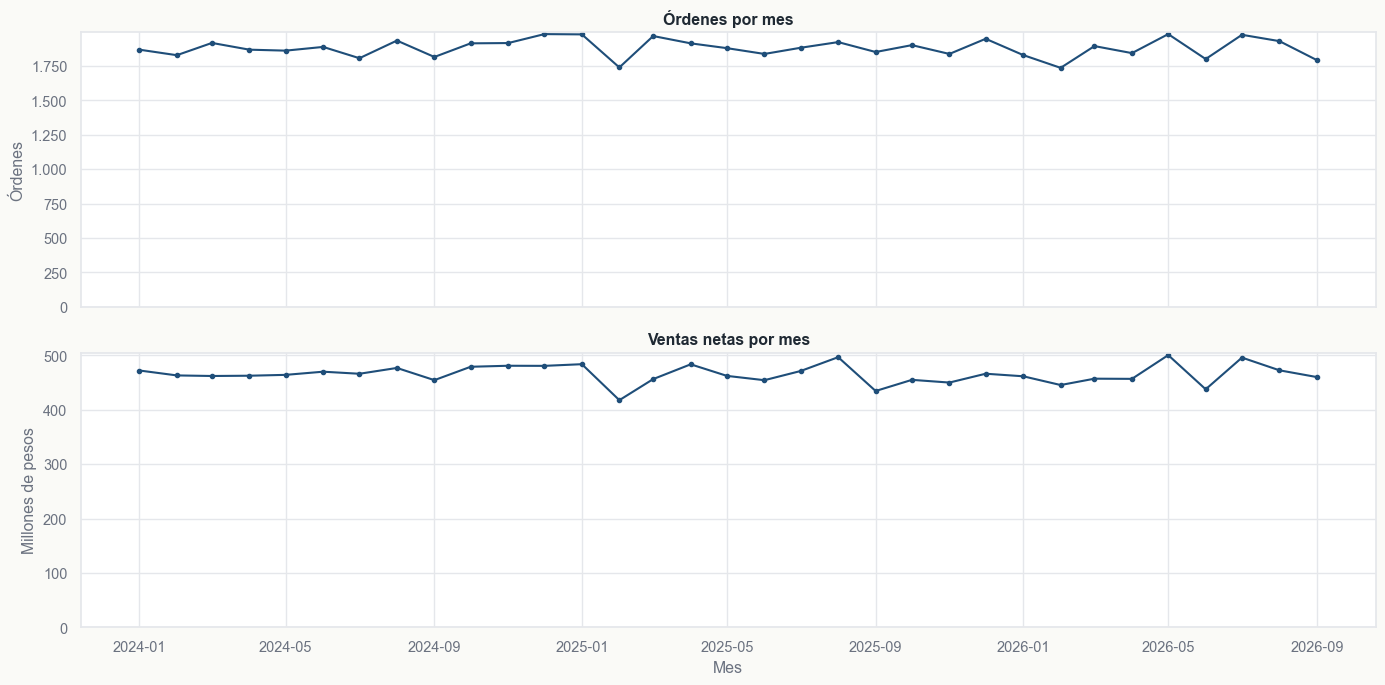

In [304]:
df_tiempo = df.assign(fecha=pd.to_datetime(df["fecha_orden"]))
mensual = df_tiempo.groupby(df_tiempo["fecha"].dt.to_period("M")).agg(
    ordenes=("id_orden", "size"), ventas_netas=("valor_neto_cop", "sum"))
mensual.index = mensual.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(mensual.index, mensual["ordenes"], color=AZUL, marker="o", markersize=3)
axes[0].set_title("Órdenes por mes")
axes[0].set_ylabel("Órdenes")
axes[0].yaxis.set_major_formatter(miles)
axes[1].plot(mensual.index, mensual["ventas_netas"] / 1e6, color=AZUL, marker="o", markersize=3)
axes[1].set_title("Ventas netas por mes")
axes[1].set_ylabel("Millones de pesos")
axes[1].set_xlabel("Mes")
for ax in axes:
    ax.set_ylim(bottom=0)
plt.tight_layout()
guardar(fig, "ordenes_y_ventas_por_mes.png")
plt.show()

In [305]:
# Comparación por año: completo y sobre el mismo periodo (enero a septiembre)
por_anio = df_tiempo.groupby(df_tiempo["fecha"].dt.year).agg(
    meses=("fecha", lambda f: f.dt.month.nunique()),
    ordenes=("id_orden", "size"),
    ventas_netas_millones=("valor_neto_cop", lambda v: v.sum() / 1e6))

ene_sep = df_tiempo[df_tiempo["fecha"].dt.month <= 9]
por_anio["ordenes_ene_sep"] = ene_sep.groupby(ene_sep["fecha"].dt.year).size()
por_anio["ventas_ene_sep_millones"] = ene_sep.groupby(ene_sep["fecha"].dt.year)["valor_neto_cop"].sum() / 1e6
por_anio.index.name = "año"
por_anio

,meses,ordenes,ventas_netas_millones,ordenes_ene_sep,ventas_ene_sep_millones
año,,,,,
2024,12,22584,"5,634.82",16776,"4,193.49"
2025,12,22644,"5,534.10",16962,"4,162.25"
2026,9,16772,"4,189.48",16772,"4,189.48"


In [306]:
# Octubre a diciembre: solo existe en 2024 y 2025. ¿El cierre del año vende más que el resto del año?
completos = df_tiempo[df_tiempo["fecha"].dt.year.isin([2024, 2025])]
periodo = np.where(completos["fecha"].dt.month <= 9, "Enero–septiembre", "Octubre–diciembre")

cierre = completos.groupby([completos["fecha"].dt.year.rename("año"), pd.Series(periodo, index=completos.index, name="periodo")]).agg(
    meses=("fecha", lambda f: f.dt.month.nunique()),
    ordenes=("id_orden", "size"),
    ventas_netas_millones=("valor_neto_cop", lambda v: v.sum() / 1e6))
cierre["ordenes_por_mes"] = cierre["ordenes"] / cierre["meses"]
cierre["ventas_por_mes_millones"] = cierre["ventas_netas_millones"] / cierre["meses"]
cierre

meses  ordenes  ventas_netas_millones  \
año  periodo                                                    
2024 Enero–septiembre       9    16776               4,193.49   
     Octubre–diciembre      3     5808               1,441.33   
2025 Enero–septiembre       9    16962               4,162.25   
     Octubre–diciembre      3     5682               1,371.84   

                        ordenes_por_mes  ventas_por_mes_millones  
año  periodo                                                      
2024 Enero–septiembre          1,864.00                   465.94  
     Octubre–diciembre         1,936.00                   480.44  
2025 Enero–septiembre          1,884.67                   462.47  
     Octubre–diciembre         1,894.00                   457.28

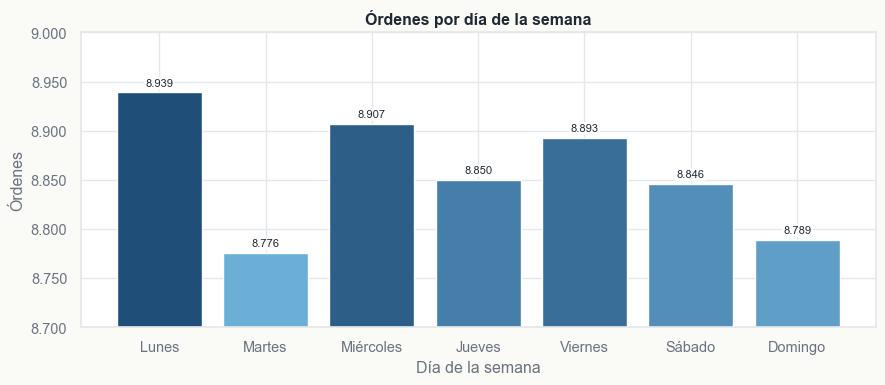

,órdenes
Lunes,8939
Martes,8776
Miércoles,8907
Jueves,8850
Viernes,8893
Sábado,8846
Domingo,8789


In [307]:
dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
por_dia = df_tiempo.groupby(df_tiempo["fecha"].dt.dayofweek).size()
por_dia.index = dias

fig, ax = plt.subplots(figsize=(9, 4))
barras = ax.bar(por_dia.index, por_dia.values, color=degradado(por_dia.values))
etiquetar(ax, barras, [fmt_miles(v) for v in por_dia.values])
ax.set_ylim(8700, 9000)
ax.set_title("Órdenes por día de la semana")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Órdenes")
ax.yaxis.set_major_formatter(miles)
plt.tight_layout()
guardar(fig, "ordenes_por_dia_semana.png")
plt.show()
por_dia.to_frame("órdenes")

**Hallazgos.**

- **Estabilidad mensual.** La actividad de la plataforma es muy estable: cada mes se registran entre **1.735** y **1.980** órdenes y entre **$418** y **$501 millones** en ventas netas, sin una tendencia clara de crecimiento ni de caída.
- **Estacionalidad.** No hay temporadas marcadas: no aparecen picos en diciembre ni en otras fechas comerciales, y los meses más bajos son febrero de 2025 y febrero de 2026, que tienen menos días.
- **Día de la semana.** Tampoco hay diferencias por día: cada día de la semana concentra entre **8.776** y **8.939** órdenes.
- **Comparación entre años.** Si se miran los totales, 2026 parece haber caído (**16.772** órdenes frente a **22.644** en 2025), pero es solo porque le falta la información de los meses octubre, noviembre y diciembre. Comparando el mismo periodo de enero a septiembre, los tres años son prácticamente iguales: **16.776** órdenes en 2024, **16.962** en 2025 y **16.772** en 2026, con ventas de entre **$4.162** y **$4.193 millones** en cada caso.
- **Cierre del año (octubre a diciembre).** Este periodo solo existe en 2024 y 2025. En 2024 sumó **5.808** órdenes y **$1.441 millones**, y en 2025 **5.682** órdenes y **$1.372 millones**. Comparado mes a mes con el resto del año, el cierre no muestra un aumento consistente: en 2024 vendió un poco más que de enero a septiembre, pero en 2025 quedó prácticamente igual. Es decir, la plataforma no tiene una temporada alta de fin de año, y por eso no se pierde mucho al comparar los años solo de enero a septiembre.

## 2.7 Variables de resultado: entrega, devoluciones y calificación

Este proyecto no tiene una variable objetivo, como sí la tendría un modelo de predicción. En cambio, las variables de esta sección son las que están detrás de los seis KPI definidos en la sección 1.5 del notebook 01, y revisarlas por segmento permite saber, antes de construir el dashboard, dónde hay diferencias reales que valga la pena mostrar y dónde no.

In [308]:
df_kpi = df.assign(
    a_tiempo=df["entrega_a_tiempo"].eq("Sí"),
    devuelta=df["devolucion_30d"].eq("Sí"),
)

def calcular_kpis(grupo):
    return pd.Series({
        "órdenes": len(grupo),
        "ventas netas (millones)": grupo["valor_neto_cop"].sum() / 1e6,
        "ticket promedio": grupo["valor_neto_cop"].mean(),
        "descuento promedio (%)": grupo["descuento_pct"].mean(),
        "% entrega a tiempo": grupo["a_tiempo"].mean() * 100,
        "% devoluciones": grupo["devuelta"].mean() * 100,
        "calificación promedio": grupo["calificacion_producto_1a5"].mean(),
    })

calcular_kpis(df_kpi).to_frame("valor global")

,valor global
órdenes,"62,000.00"
ventas netas (millones),"15,358.40"
ticket promedio,"247,716.08"
descuento promedio (%),9.55
% entrega a tiempo,88.07
% devoluciones,6.66
calificación promedio,4.27


In [309]:
dimensiones = ["categoria", "region", "fuente_trafico", "metodo_pago", "operador_entrega", "dias_prometidos"]
tablas_kpi = {col: df_kpi.groupby(col).apply(calcular_kpis, include_groups=False) for col in dimensiones}

for col, tabla in tablas_kpi.items():
    print(f"\n=== KPI por {col} ===")
    print(tabla.round(2).to_string())


=== KPI por categoria ===
             órdenes  ventas netas (millones)  ticket promedio  descuento promedio (%)  % entrega a tiempo  % devoluciones  calificación promedio
categoria                                                                                                                                        
Belleza     7,363.00                   771.31       104,755.23                    9.53               87.90            6.46                   4.27
Deportes    6,838.00                 1,303.79       190,668.37                    9.62               88.65            6.65                   4.29
Hogar      10,617.00                 2,340.71       220,468.58                    9.56               88.33            6.84                   4.26
Juguetes    5,569.00                   657.32       118,032.29                    9.57               87.93            6.39                   4.28
Mascotas    6,181.00                   562.16        90,950.46                    9.39           

In [310]:
# ¿Qué tan grande es la diferencia entre el mejor y el peor segmento en cada KPI?
kpis_comparables = ["ticket promedio", "descuento promedio (%)", "% entrega a tiempo",
                    "% devoluciones", "calificación promedio"]
pd.DataFrame({col: tabla[kpis_comparables].max() - tabla[kpis_comparables].min()
              for col, tabla in tablas_kpi.items()}).T.round(2)

,ticket promedio,descuento promedio (%),% entrega a tiempo,% devoluciones,calificación promedio
categoria,"520,020.56",0.23,1.11,0.92,0.02
region,"8,852.57",0.28,1.00,0.88,0.03
fuente_trafico,"3,710.57",0.11,1.11,0.57,0.02
metodo_pago,"3,841.56",0.24,0.42,0.15,0.01
operador_entrega,"3,364.96",0.04,0.35,0.20,0.01
dias_prometidos,"8,549.38",0.16,0.61,1.84,0.03


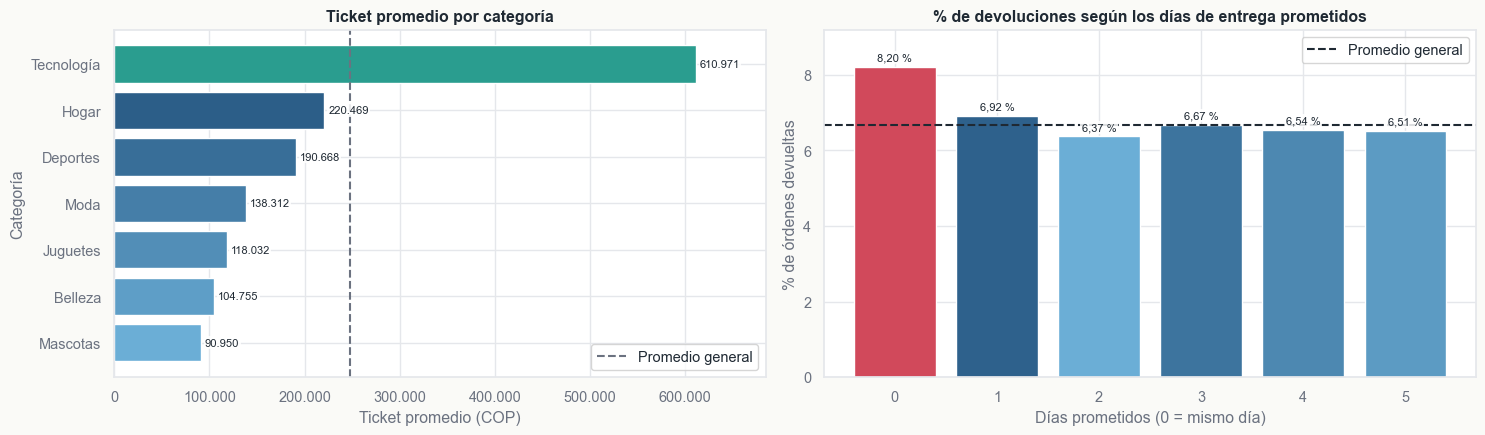

In [311]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ticket = tablas_kpi["categoria"]["ticket promedio"].sort_values()
barras = axes[0].barh(ticket.index, ticket.values, color=destacar(ticket.values, VERDE))
etiquetar(axes[0], barras, [fmt_miles(v) for v in ticket.values])
axes[0].margins(x=0.12)
axes[0].axvline(df["valor_neto_cop"].mean(), color=GRIS_MEDIO, linestyle="--", label="Promedio general")
axes[0].set_title("Ticket promedio por categoría")
axes[0].set_xlabel("Ticket promedio (COP)")
axes[0].set_ylabel("Categoría")
axes[0].xaxis.set_major_formatter(miles)
axes[0].legend()

devoluciones = tablas_kpi["dias_prometidos"]["% devoluciones"]
barras = axes[1].bar(devoluciones.index.astype(str), devoluciones.values,
                     color=destacar(devoluciones.values, ROJO))
etiquetar(axes[1], barras, [fmt_pct(v, 2) for v in devoluciones.values])
axes[1].margins(y=0.12)
axes[1].axhline(df_kpi["devuelta"].mean() * 100, color=GRIS_TEXTO, linestyle="--", label="Promedio general")
axes[1].set_title("% de devoluciones según los días de entrega prometidos")
axes[1].set_xlabel("Días prometidos (0 = mismo día)")
axes[1].set_ylabel("% de órdenes devueltas")
axes[1].legend()
plt.tight_layout()
guardar(fig, "ticket_categoria_y_devoluciones_promesa.png")
plt.show()

In [312]:
# Calificación y devoluciones según los días de retraso
por_retraso = df_kpi.groupby("dias_retraso").agg(
    órdenes=("id_orden", "size"),
    calificación_promedio=("calificacion_producto_1a5", "mean"),
    pct_devoluciones=("devuelta", lambda d: d.mean() * 100))
por_retraso

,órdenes,calificación_promedio,pct_devoluciones
dias_retraso,,,
0,54604,4.31,6.61
1,1860,4.19,6.83
2,1823,4.07,7.24
3,1879,3.98,6.97
4,1834,3.89,7.03


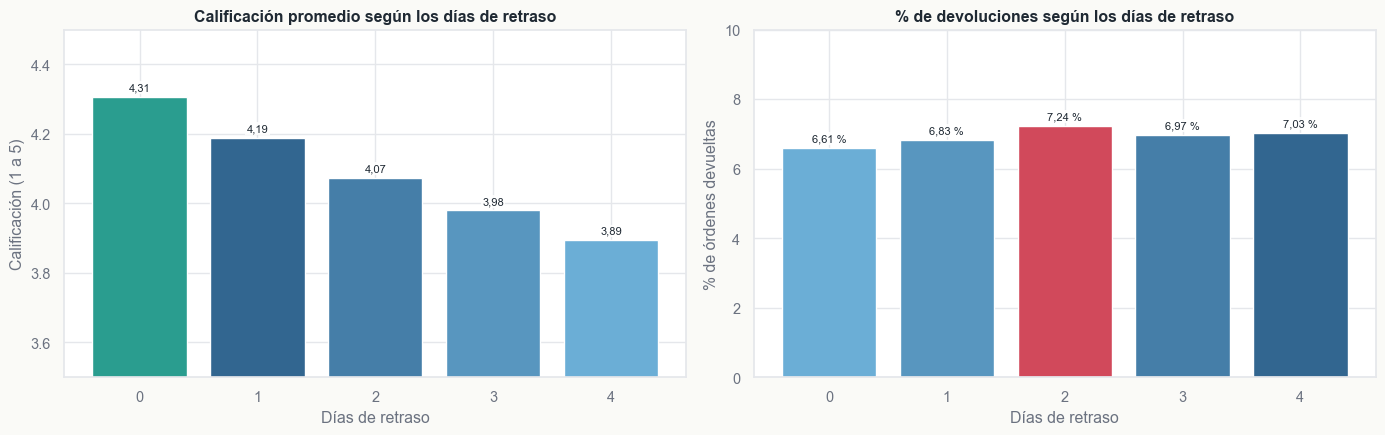

In [313]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
barras = axes[0].bar(por_retraso.index.astype(str), por_retraso["calificación_promedio"],
                     color=destacar(por_retraso["calificación_promedio"], VERDE))
etiquetar(axes[0], barras, [f"{v:.2f}".replace(".", ",") for v in por_retraso["calificación_promedio"]])
axes[0].set_ylim(3.5, 4.5)
axes[0].set_title("Calificación promedio según los días de retraso")
axes[0].set_xlabel("Días de retraso")
axes[0].set_ylabel("Calificación (1 a 5)")

barras = axes[1].bar(por_retraso.index.astype(str), por_retraso["pct_devoluciones"],
                     color=destacar(por_retraso["pct_devoluciones"], ROJO))
etiquetar(axes[1], barras, [fmt_pct(v, 2) for v in por_retraso["pct_devoluciones"]])
axes[1].set_ylim(0, 10)
axes[1].set_title("% de devoluciones según los días de retraso")
axes[1].set_xlabel("Días de retraso")
axes[1].set_ylabel("% de órdenes devueltas")
plt.tight_layout()
guardar(fig, "calificacion_y_devoluciones_por_retraso.png")
plt.show()

In [314]:
# Ticket promedio y devoluciones por rangos de descuento
rangos = pd.cut(df_kpi["descuento_pct"], bins=[0, 5, 10, 15, 20, 100], right=False,
                labels=["0–5 %", "5–10 %", "10–15 %", "15–20 %", "20 % o más"])
por_descuento = df_kpi.groupby(rangos, observed=True).agg(
    órdenes=("id_orden", "size"),
    valor_bruto_promedio=("valor_bruto_cop", "mean"),
    ticket_promedio=("valor_neto_cop", "mean"),
    pct_devoluciones=("devuelta", lambda d: d.mean() * 100),
    calificación_promedio=("calificacion_producto_1a5", "mean"))
por_descuento.index.name = "rango de descuento"
por_descuento

,órdenes,valor_bruto_promedio,ticket_promedio,pct_devoluciones,calificación_promedio
rango de descuento,,,,,
0–5 %,19117,"271,128.84","266,852.34",6.49,4.27
5–10 %,14927,"275,869.78","254,975.55",6.50,4.28
10–15 %,13672,"274,072.39","240,209.51",6.63,4.26
15–20 %,8998,"273,265.01","226,202.72",7.12,4.28
20 % o más,5286,"280,133.47","214,045.45",7.02,4.28


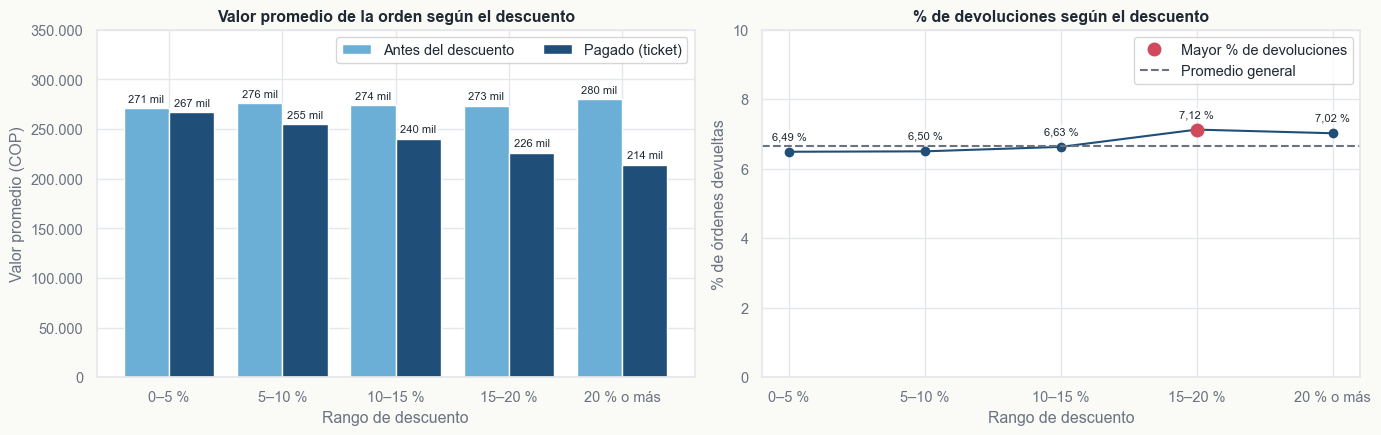

In [315]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(por_descuento))
antes = axes[0].bar(x - 0.2, por_descuento["valor_bruto_promedio"], width=0.4, color=AZUL_CLARO, label="Antes del descuento")
pagado = axes[0].bar(x + 0.2, por_descuento["ticket_promedio"], width=0.4, color=AZUL, label="Pagado (ticket)")
etiquetar(axes[0], antes, [f"{v / 1000:.0f} mil" for v in por_descuento["valor_bruto_promedio"]])
etiquetar(axes[0], pagado, [f"{v / 1000:.0f} mil" for v in por_descuento["ticket_promedio"]])
axes[0].set_xticks(x, por_descuento.index)
axes[0].set_title("Valor promedio de la orden según el descuento")
axes[0].set_xlabel("Rango de descuento")
axes[0].set_ylabel("Valor promedio (COP)")
axes[0].yaxis.set_major_formatter(miles)
axes[0].set_ylim(0, 350000)
axes[0].legend(loc="upper right", ncol=2)

axes[1].plot(por_descuento.index.astype(str), por_descuento["pct_devoluciones"], color=AZUL, marker="o")
for etiqueta, valor in zip(por_descuento.index.astype(str), por_descuento["pct_devoluciones"]):
    axes[1].annotate(fmt_pct(valor, 2), (etiqueta, valor), textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=8, color=GRIS_TEXTO,
                     bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1})
mayor = por_descuento["pct_devoluciones"].idxmax()
axes[1].plot([str(mayor)], [por_descuento.loc[mayor, "pct_devoluciones"]], "o", color=ROJO, markersize=9,
             label="Mayor % de devoluciones")
axes[1].axhline(df_kpi["devuelta"].mean() * 100, color=GRIS_MEDIO, linestyle="--", label="Promedio general")
axes[1].set_ylim(0, 10)
axes[1].set_title("% de devoluciones según el descuento")
axes[1].set_xlabel("Rango de descuento")
axes[1].set_ylabel("% de órdenes devueltas")
axes[1].legend()
plt.tight_layout()
guardar(fig, "ticket_y_devoluciones_por_descuento.png")
plt.show()

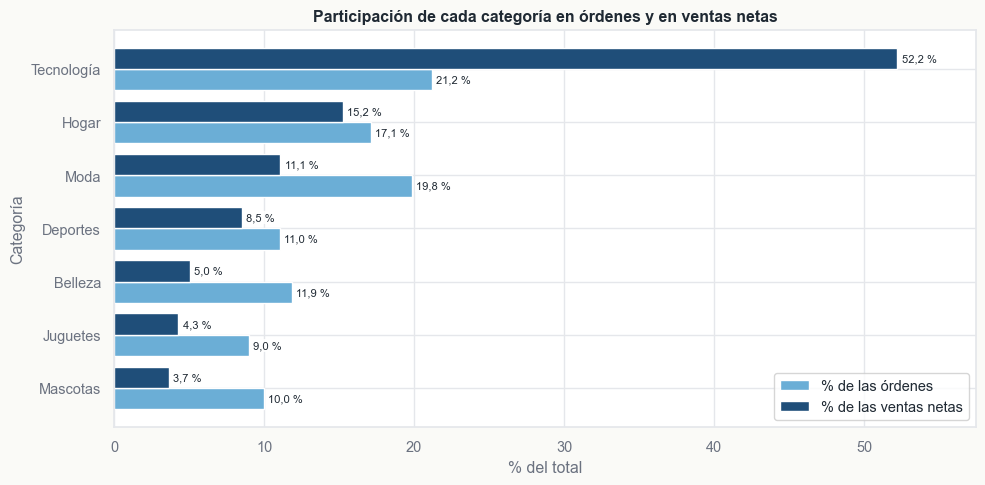

,% de las órdenes,% de las ventas netas
categoria,,
Mascotas,10.00,3.70
Juguetes,9.00,4.30
Belleza,11.90,5.00
Deportes,11.00,8.50
Moda,19.80,11.10
Hogar,17.10,15.20
Tecnología,21.20,52.20


In [316]:
# Participación de cada categoría en las ventas netas frente a su participación en órdenes
participacion = pd.DataFrame({
    "% de las órdenes": df["categoria"].value_counts(normalize=True) * 100,
    "% de las ventas netas": df.groupby("categoria")["valor_neto_cop"].sum() / df["valor_neto_cop"].sum() * 100,
}).sort_values("% de las ventas netas")

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(participacion))
ordenes = ax.barh(y - 0.2, participacion["% de las órdenes"], height=0.4, color=AZUL_CLARO, label="% de las órdenes")
ventas = ax.barh(y + 0.2, participacion["% de las ventas netas"], height=0.4, color=AZUL, label="% de las ventas netas")
etiquetar(ax, ordenes, [fmt_pct(v) for v in participacion["% de las órdenes"]])
etiquetar(ax, ventas, [fmt_pct(v) for v in participacion["% de las ventas netas"]])
ax.margins(x=0.1)
ax.set_yticks(y, participacion.index)
ax.set_title("Participación de cada categoría en órdenes y en ventas netas")
ax.set_xlabel("% del total")
ax.set_ylabel("Categoría")
ax.legend()
plt.tight_layout()
guardar(fig, "participacion_categorias.png")
plt.show()
participacion.round(1)

**Hallazgos.**

- **La mayoría de los segmentos se comporta igual.** Por región, fuente de tráfico, medio de pago y operador, los KPI casi no cambian (por ejemplo, la entrega a tiempo está entre **87,5 %** y **88,7 %** en todos). Las diferencias reales están en solo tres lugares: la categoría, el descuento y el retraso.
- **Tecnología sostiene el ingreso.** Con el **21,2 %** de las órdenes genera el **52,2 %** de las ventas netas, porque su ticket promedio (**$610.971**) es más del doble que el de cualquier otra categoría.
- **Los descuentos solo reducen el ticket.** El valor de la orden antes del descuento es casi igual en todos los rangos, así que a más descuento, menos se cobra: el ticket cae de **$266.852** (menos del 5 %) a **$214.045** (20 % o más). Las devoluciones suben apenas, de **6,5 %** a **7,1 %**.
- ~~**El retraso baja la calificación.** Pasa de **4,31** sin retraso a **3,89** con cuatro días de retraso, pero casi no cambia las devoluciones. Lo que sí se asocia con más devoluciones es la promesa de entrega el mismo día: esas órdenes tienen un **8,20 %** de devoluciones, frente a entre **6,37 %** y **6,92 %** en los demás plazos.
- **Implicación para el dashboard.** Las vistas principales deben ser la categoría (ingreso), los rangos de descuento (ticket) y los días de retraso (calificación). Las demás dimensiones sirven como filtros para explorar.

## 2.8 Conclusiones: qué se debe tratar en la fase de preparación

El conjunto de datos llega en muy buen estado: no tiene duplicados, valores imposibles, errores de escritura ni contradicciones entre columnas, y solo una variable tiene valores vacíos. Por eso, la fase 03 se centra más en transformar y crear variables para el dashboard que en limpiar. Estas son las acciones concretas, agrupadas por tipo.

### Eliminar

| Qué | Motivo |
|---|---|
| Columna `entrega_a_tiempo` | Repite la información de `dias_retraso`: una orden está a tiempo si y solo si tiene 0 días de retraso, sin ninguna excepción en las 62.000 órdenes. `dias_retraso` aporta más información, porque además dice cuánto fue el retraso. |

### Transformar

| Qué | Motivo |
|---|---|
| `fecha_orden` de texto a fecha | Llegó como texto; como fecha permite agrupar por mes, trimestre y año y construir el análisis temporal. |
| `devolucion_30d` de "Sí"/"No" a 1/0 | Permite calcular el % de devoluciones directamente como un promedio. |
| `calificacion_producto_1a5` de decimal a entero (`Int64`) | Solo toma valores enteros de 1 a 5; llegó como decimal únicamente porque tiene valores vacíos. |
| Columnas de texto a tipo categoría | Ocupan menos memoria y fijan el orden de las categorías en tablas y gráficos. |

### Tratar

| Qué | Motivo |
|---|---|
| **1.364 calificaciones vacías (2,2 %)** | Se dejan vacías y se excluyen del promedio. Están repartidas al azar entre segmentos, así que imputarlas no aporta información y sí podría alterar el KPI. |
| **5.633 órdenes atípicas por valor (9,1 %)** | Se conservan. Son compras legítimas con un valor alto, el 84,8 % de Tecnología; eliminarlas quitaría la mitad del ingreso. Se usa la mediana como apoyo al promedio. |
| Diferencias de redondeo en `valor_neto_cop` | No se corrigen. Son de pocos pesos (menos del 0,02 %) y el valor neto es lo que el cliente realmente pagó. |

### Crear

| Qué | Motivo |
|---|---|
| Año, trimestre, mes, nombre del mes y día de la semana | Dimensiones para el análisis temporal y los filtros de fecha. |
| Tabla calendario (1 de enero de 2024 a 30 de septiembre de 2026) | Estructura estándar de tiempo para el modelo de datos del dashboard. |
| Indicador de periodo comparable (enero a septiembre) | Permite comparar años sin el sesgo de que 2026 está incompleto. |
| `valor_descuento_cop` (bruto − neto) | Muestra en pesos cuánto ingreso se deja de recibir por descuentos. |
| Rango de descuento (0–5 %, 5–10 %, 10–15 %, 15–20 %, 20 % o más) | Es la forma en que el descuento muestra su efecto sobre el ticket y las devoluciones. |
| Rango de retraso (sin retraso, 1–2 días, 3–4 días) | Facilita leer el efecto del retraso sobre la calificación. |
| Tipo de promesa de entrega (mismo día, 1–2 días, 3 o más días) | Aísla la entrega el mismo día, que tiene más devoluciones. |
| Indicador de orden con alto valor | Identifica las órdenes atípicas sin eliminarlas. |

### Conservar sin cambios

| Qué | Motivo |
|---|---|
| `id_orden` | Es único y sirve para contar órdenes. |
| `ciudad_destino`, `departamento_destino`, `region` | Coherentes entre sí y sin errores de escritura; forman la jerarquía geográfica. |
| `categoria`, `tipo_vendedor`, `dispositivo`, `fuente_trafico`, `metodo_pago`, `operador_entrega` | Completas, sin errores de escritura y sin categorías demasiado pequeñas. |
| `valor_bruto_cop`, `valor_neto_cop`, `descuento_pct` | Completas, sin valores imposibles y coherentes entre sí. |
| `dias_prometidos`, `dias_retraso` | Completas y sin valores negativos. `dias_retraso` es además la base del KPI de % de entregas a tiempo (órdenes con 0 días de retraso). |